<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Fractal002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 2000/2000 [00:53<00:00, 37.43it/s]


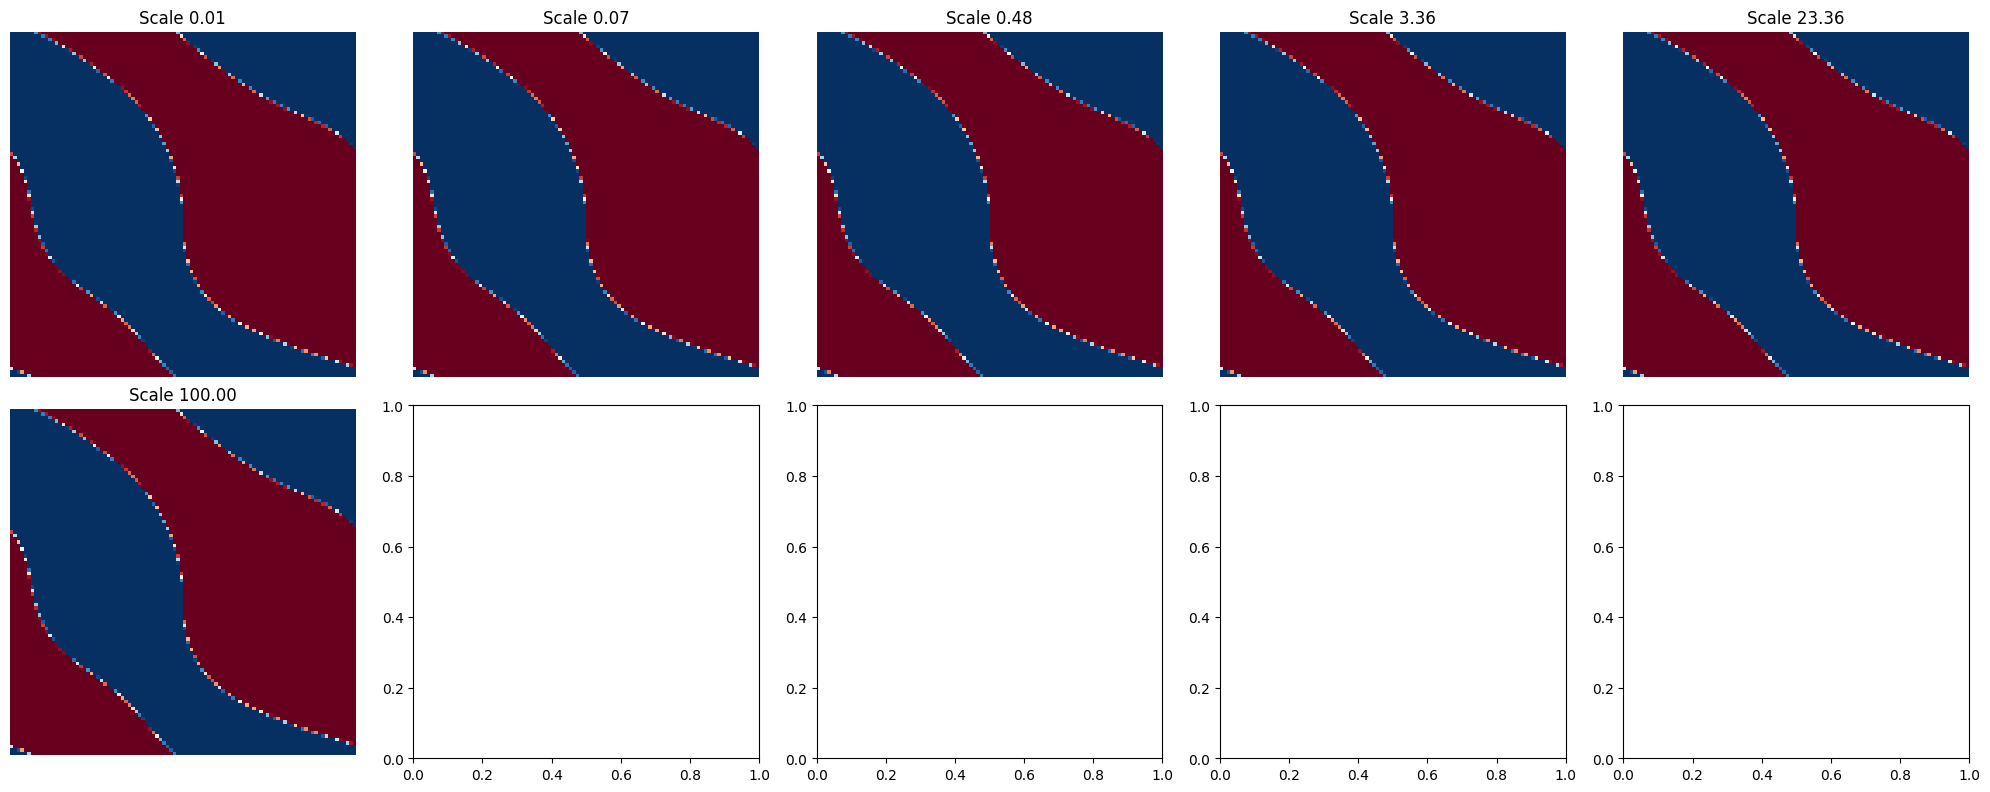

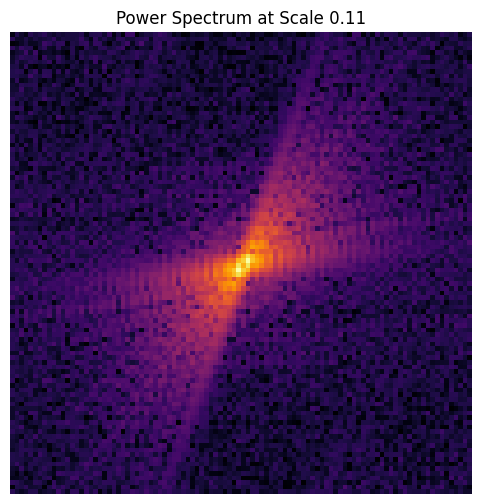

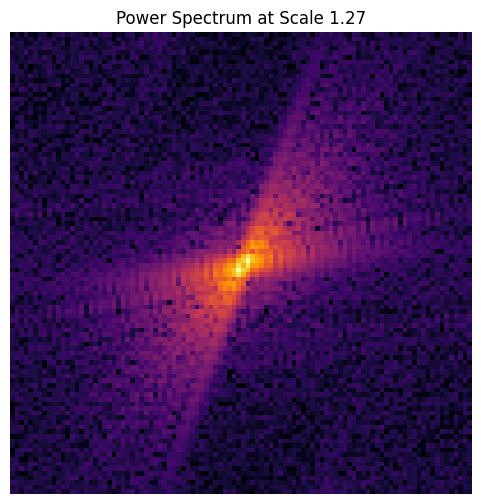

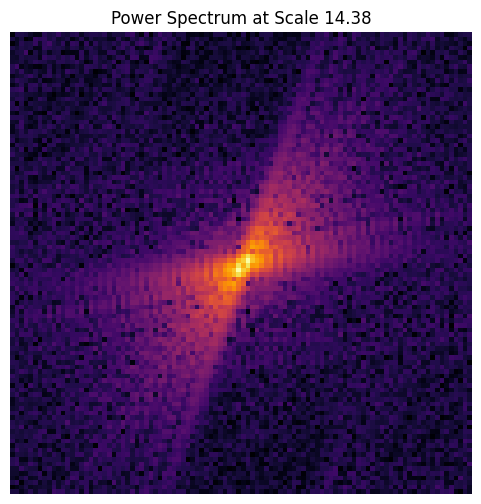

In [ ]:
# HES_Fractal_Test: Adding Scale Dimension to Original

import numpy as np
from scipy.fft import fft2, ifft2, fftshift
from tqdm import tqdm
import matplotlib.pyplot as plt

# Parameters (same as original)
alpha, beta, gamma, delta = 0.1, 0.01, 0.2, 0.02
T_max = 2000
L = 100  # Spatial size
N_scales = 20  # NEW: Number of scale layers
seed = 42

# Initialize: Random field at EVERY scale
np.random.seed(seed)
Phi = np.random.randn(N_scales, L, L)  # [scale, x, y]

# Scale coordinates: log-spaced from "inward" to "outward"
scales = np.logspace(-2, 2, N_scales)  # 0.01 to 100

def laplacian_spatial(field):
    """Spatial Laplacian (original alpha drive)"""
    return (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) -
        4 * field
    )

def laplacian_scale(field):
    """NEW: Laplacian in SCALE dimension (bidirectional coupling)"""
    return (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) -
        2 * field
    )

# Evolution
for t in tqdm(range(T_max)):
    # Original spatial dynamics at EACH scale
    spatial_term = alpha * np.array([laplacian_spatial(Phi[s]) for s in range(N_scales)])

    # NEW: Scale coupling (inward/outward interaction)
    scale_term = 0.05 * laplacian_scale(Phi)  # Coupling strength

    # Original contraction + nonlinearity
    contraction = -beta * Phi
    nonlinear = gamma * np.tanh(Phi)
    noise = delta * np.random.randn(N_scales, L, L)

    # Update
    Phi += spatial_term + scale_term + contraction + nonlinear + noise

# Analysis: Check if patterns are self-similar across scales
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, s in enumerate([0, 4, 8, 12, 16, 19]):  # Sample scales
    ax = axes[i // 5, i % 5]
    ax.imshow(Phi[s], cmap='RdBu', vmin=-2, vmax=2)
    ax.set_title(f'Scale {scales[s]:.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Check: Are patterns circular at each scale?
for s in [5, 10, 15]:  # Check a few scales
    spectrum = np.abs(fftshift(fft2(Phi[s])))**2
    plt.figure(figsize=(6, 6))
    plt.imshow(np.log1p(spectrum), cmap='inferno')
    plt.title(f'Power Spectrum at Scale {scales[s]:.2f}')
    plt.axis('off')
    plt.show()